# Multimodal Sentiment Analysis Using Text, Audio, and Video

## Introduction

Multimodal sentiment analysis is the task of identifying sentiment or emotion by combining more than one type of input data. In this project, the intended modalities are:

1. **Text**: captions, transcripts, or spoken words.
2. **Audio**: tone, pitch, voice energy, and rhythm.
3. **Video**: facial expressions, movement, and visual cues.

The dataset added to this folder is `LabeledText.xlsx`. It contains text captions and sentiment labels. Since it does not include audio or video files, this notebook automatically uses the real text data and safe fallback vectors for missing audio/video. If matching audio/video files are added later, the same notebook can use them.

Combining modalities is useful because text alone can miss tone and facial expression. For example, the same sentence may express different emotions depending on how it is spoken and how the speaker looks.

Real-world uses include interview analysis, customer feedback analysis, social media analysis, online learning feedback, and human-computer interaction.


## Problem Statement

The problem is to classify sentiment using multimodal information. In this notebook, the available dataset provides text captions and sentiment labels:

- `Caption`: input text.
- `LABEL`: target sentiment class.

The labels in this dataset are:

- `negative`
- `neutral`
- `positive`

The pipeline performs text preprocessing, feature extraction, optional audio/video feature extraction, early fusion, model training, evaluation, and final prediction.


## 1. Import Required Libraries

This section imports the required libraries.

The notebook is designed to be robust:

- If TensorFlow is available, it trains a Keras neural network.
- If TensorFlow is not available, it trains a small neural network implemented with NumPy.
- If scikit-learn is available, it uses scikit-learn utilities.
- If scikit-learn is not available, it uses simple fallback implementations.
- If `librosa` or OpenCV is missing, missing audio/video features are replaced with zero vectors.

This makes the notebook runnable even in lightweight environments.


In [31]:
import os
import re
import math
import hashlib
import warnings
from pathlib import Path
from collections import Counter, defaultdict

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd


# display() exists inside Jupyter. This fallback lets the same code run as a
# plain Python smoke test.
try:
    display
except NameError:
    try:
        from IPython.display import display
    except Exception:
        display = print


# Optional plotting libraries.
try:
    import matplotlib.pyplot as plt

    MATPLOTLIB_AVAILABLE = True
except Exception as error:
    MATPLOTLIB_AVAILABLE = False
    plt = None
    print("matplotlib is not available. Plots will be skipped.")
    print("Import message:", str(error)[:180])

try:
    import seaborn as sns

    SEABORN_AVAILABLE = True
except Exception as error:
    SEABORN_AVAILABLE = False
    sns = None
    print("seaborn is not available. Confusion matrix heatmap will use table fallback.")
    print("Import message:", str(error)[:180])


# Optional scikit-learn utilities.
try:
    from sklearn.model_selection import train_test_split as sklearn_train_test_split
    from sklearn.preprocessing import LabelEncoder as SklearnLabelEncoder
    from sklearn.preprocessing import StandardScaler as SklearnStandardScaler
    from sklearn.feature_extraction.text import TfidfVectorizer as SklearnTfidfVectorizer
    from sklearn.metrics import classification_report as sklearn_classification_report
    from sklearn.metrics import confusion_matrix as sklearn_confusion_matrix
    from sklearn.metrics import precision_recall_fscore_support as sklearn_prfs

    SKLEARN_AVAILABLE = True
except Exception as error:
    SKLEARN_AVAILABLE = False
    print("scikit-learn is not available. NumPy fallback utilities will be used.")
    print("Import message:", str(error)[:180])


# Optional TensorFlow/Keras.
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, Input
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.utils import to_categorical

    TF_AVAILABLE = True
except Exception as error:
    TF_AVAILABLE = False
    tf = None
    print("TensorFlow is not available. NumPy neural network fallback will be used.")
    print("Import message:", str(error)[:180])

    def to_categorical(y, num_classes):
        y = np.asarray(y, dtype=int)
        return np.eye(num_classes, dtype=np.float32)[y]


# Optional audio library.
try:
    import librosa

    LIBROSA_AVAILABLE = True
except Exception as error:
    LIBROSA_AVAILABLE = False
    librosa = None
    print("librosa is not available. Missing audio will use zero-vector fallback.")
    print("Import message:", str(error)[:180])


# Optional video library.
try:
    import cv2

    CV2_AVAILABLE = True
except Exception as error:
    CV2_AVAILABLE = False
    cv2 = None
    print("OpenCV/cv2 is not available. Missing video will use zero-vector fallback.")
    print("Import message:", str(error)[:180])


# Optional BERT/Transformers.
try:
    from transformers import AutoTokenizer, TFAutoModel

    TRANSFORMERS_AVAILABLE = True
except Exception as error:
    TRANSFORMERS_AVAILABLE = False
    AutoTokenizer = None
    TFAutoModel = None
    print("transformers is not available. TF-IDF text features will be used.")
    print("Import message:", str(error)[:180])


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

if TF_AVAILABLE:
    tf.random.set_seed(RANDOM_STATE)

if SEABORN_AVAILABLE:
    sns.set_theme(style="whitegrid")

print("Library status")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn available:", SKLEARN_AVAILABLE)
print("TensorFlow available:", TF_AVAILABLE)
print("Matplotlib available:", MATPLOTLIB_AVAILABLE)
print("Seaborn available:", SEABORN_AVAILABLE)
print("librosa available:", LIBROSA_AVAILABLE)
print("OpenCV available:", CV2_AVAILABLE)
print("Transformers available:", TRANSFORMERS_AVAILABLE)


Library status
pandas: 2.2.1
numpy: 1.26.4
scikit-learn available: True
TensorFlow available: True
Matplotlib available: True
Seaborn available: True
librosa available: True
OpenCV available: True
Transformers available: True


## 2. Load the Dataset from `LabeledText.xlsx`

The dataset in this folder is an Excel file named `LabeledText.xlsx`.

It contains:

- `File Name`: original text file identifier.
- `Caption`: social-media style text caption.
- `LABEL`: sentiment label.

The notebook reads this Excel file directly and standardizes the columns into the format required by the multimodal pipeline:

- `text`
- `audio_path`
- `video_path`
- `label`

Because this dataset does not contain real audio/video paths, those paths are kept empty unless matching media files are found in common folders such as `audio/`, `video/`, `audios/`, or `videos/`.


In [32]:
DATASET_PATH = Path("LabeledText.xlsx")
DATASET_SHEET = "final label"

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        "LabeledText.xlsx was not found in this folder. "
        "Place the dataset beside this notebook and run again."
    )

raw_df = pd.read_excel(DATASET_PATH, sheet_name=DATASET_SHEET)

print("Dataset file:", DATASET_PATH.resolve())
print("Raw dataset shape:", raw_df.shape)
print("Columns:", list(raw_df.columns))
display(raw_df.head())


Dataset file: /Users/apple/Documents/multimodal sentiment analysis/LabeledText.xlsx
Raw dataset shape: (4869, 3)
Columns: ['File Name', 'Caption', 'LABEL']


,File Name,Caption,LABEL
0,1.txt,How I feel today #legday #jelly #aching #gym,negative
1,10.txt,@ArrivaTW absolute disgrace two carriages from...,negative
2,100.txt,This is my Valentine's from 1 of my nephews. I...,positive
3,1000.txt,betterfeelingfilms: RT via Instagram: First da...,neutral
4,1001.txt,Zoe's first love #Rattled @JohnnyHarper15,positive


## 3. Standardize Dataset Columns

The original dataset columns are renamed into a simple format used throughout the notebook.

The notebook also checks whether audio or video files exist. If media files are not found, the audio and video feature extractors will safely return zero vectors so that the end-to-end model still works.


In [33]:
TEXT_COLUMN = "Caption"
LABEL_COLUMN = "LABEL"
FILE_COLUMN = "File Name"


def build_media_index(extensions, ignore_dirs={".git", "__pycache__"}):
    '''Build a dictionary that maps file stems to media paths.'''
    index = {}
    for path in Path(".").rglob("*"):
        if not path.is_file():
            continue
        if any(part in ignore_dirs for part in path.parts):
            continue
        if path.suffix.lower() in extensions:
            index.setdefault(path.stem, str(path))
    return index


audio_index = build_media_index({".wav", ".mp3", ".flac", ".ogg", ".m4a"})
video_index = build_media_index({".mp4", ".avi", ".mov", ".mkv", ".webm"})


def lookup_media_path(file_name, media_index):
    '''Find a matching media path using the file stem.'''
    if pd.isna(file_name):
        return ""
    stem = Path(str(file_name)).stem
    return media_index.get(stem, "")


df = pd.DataFrame()
df["file_name"] = raw_df[FILE_COLUMN].astype(str)
df["text"] = raw_df[TEXT_COLUMN].astype(str)
df["label"] = raw_df[LABEL_COLUMN].astype(str).str.strip().str.lower()
df["audio_path"] = df["file_name"].apply(lambda name: lookup_media_path(name, audio_index))
df["video_path"] = df["file_name"].apply(lambda name: lookup_media_path(name, video_index))

# Remove rows with missing/blank text or labels.
df = df.replace({"": np.nan})
df = df.dropna(subset=["text", "label"]).reset_index(drop=True)
df["audio_path"] = df["audio_path"].fillna("")
df["video_path"] = df["video_path"].fillna("")

print("Standardized dataset shape:", df.shape)
print("Real audio files matched:", int((df["audio_path"] != "").sum()))
print("Real video files matched:", int((df["video_path"] != "").sum()))
print("Class distribution:")
display(df["label"].value_counts().rename_axis("label").reset_index(name="count"))
display(df.head())


Standardized dataset shape: (4869, 5)
Real audio files matched: 0
Real video files matched: 0
Class distribution:


,label,count
0,neutral,1771
1,positive,1646
2,negative,1452


,file_name,text,label,audio_path,video_path
0,1.txt,How I feel today #legday #jelly #aching #gym,negative,,
1,10.txt,@ArrivaTW absolute disgrace two carriages from...,negative,,
2,100.txt,This is my Valentine's from 1 of my nephews. I...,positive,,
3,1000.txt,betterfeelingfilms: RT via Instagram: First da...,neutral,,
4,1001.txt,Zoe's first love #Rattled @JohnnyHarper15,positive,,


## 4. Text Preprocessing

Text preprocessing prepares raw captions for feature extraction.

Steps used here:

1. Convert text to lowercase.
2. Remove URLs, mentions, and unnecessary symbols.
3. Keep hashtags as words because hashtags often contain sentiment information.
4. Remove extra spaces.
5. Handle missing values.


In [34]:
def clean_text(text):
    '''Clean social-media style text captions.'''
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = text.replace("#", " ")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

print("Dataset shape after text cleaning:", df.shape)
display(df[["text", "clean_text", "label"]].head(10))


Dataset shape after text cleaning: (4775, 6)


,text,clean_text,label
0,How I feel today #legday #jelly #aching #gym,how i feel today legday jelly aching gym,negative
1,@ArrivaTW absolute disgrace two carriages from...,absolute disgrace two carriages from bangor ha...,negative
2,This is my Valentine's from 1 of my nephews. I...,this is my valentine s from 1 of my nephews i ...,positive
3,betterfeelingfilms: RT via Instagram: First da...,betterfeelingfilms rt via instagram first day ...,neutral
4,Zoe's first love #Rattled @JohnnyHarper15,zoe s first love rattled,positive
5,Chaotic Love - giclee print ?65 at #art #love ...,chaotic love giclee print 65 at art love chaot...,positive
6,They gna be mad when I reach that goal though....,they gna be mad when i reach that goal though ...,negative
7,On day 9.. It's now in my daily routine.. Feel...,on day 9 it s now in my daily routine feeling ...,negative
8,#ANIMALABUSE #TORONTO #PUPPY #TORTURE WE OFFER...,animalabuse toronto puppy torture we offer 1k ...,neutral
9,Mike will not accept this plastic rose. @wfaam...,mike will not accept this plastic rose rejected,negative


## 5. Text Feature Extraction: BERT Option and TF-IDF Default

Text must be converted into numerical features before model training.

This notebook supports two approaches:

1. **BERT embeddings** if TensorFlow and Transformers are available.
2. **TF-IDF features** as the default lightweight approach.

For this dataset, TF-IDF is a practical default because the captions are short and the dataset has thousands of rows. BERT can be enabled by setting:

```python
USE_BERT_IF_AVAILABLE = True
```

The fallback TF-IDF implementation makes the notebook work even when scikit-learn is not installed.


In [35]:
USE_BERT_IF_AVAILABLE = False
ALLOW_BERT_MODEL_DOWNLOAD = False
BERT_MODEL_NAME = "distilbert-base-uncased"
MAX_TFIDF_FEATURES = 1200


class SimpleTfidfVectorizer:
    '''Small TF-IDF fallback used when scikit-learn is unavailable.'''

    def __init__(self, max_features=1200, min_df=1):
        self.max_features = max_features
        self.min_df = min_df
        self.vocabulary_ = {}
        self.idf_ = None

    def _tokenize(self, text):
        return re.findall(r"[a-z0-9]+", str(text).lower())

    def fit(self, texts):
        document_frequency = Counter()
        term_frequency = Counter()
        n_documents = len(texts)

        for text in texts:
            tokens = self._tokenize(text)
            term_frequency.update(tokens)
            document_frequency.update(set(tokens))

        valid_terms = [
            term for term, df_count in document_frequency.items()
            if df_count >= self.min_df
        ]
        valid_terms.sort(key=lambda term: (-term_frequency[term], term))
        selected_terms = valid_terms[: self.max_features]

        self.vocabulary_ = {term: idx for idx, term in enumerate(selected_terms)}
        self.idf_ = np.zeros(len(self.vocabulary_), dtype=np.float32)

        for term, idx in self.vocabulary_.items():
            df_count = document_frequency[term]
            self.idf_[idx] = math.log((1 + n_documents) / (1 + df_count)) + 1

        return self

    def transform(self, texts):
        matrix = np.zeros((len(texts), len(self.vocabulary_)), dtype=np.float32)

        for row_index, text in enumerate(texts):
            tokens = self._tokenize(text)
            if not tokens:
                continue

            counts = Counter(tokens)
            total_tokens = sum(counts.values())

            for token, count in counts.items():
                col_index = self.vocabulary_.get(token)
                if col_index is not None:
                    tf = count / total_tokens
                    matrix[row_index, col_index] = tf * self.idf_[col_index]

        norms = np.linalg.norm(matrix, axis=1, keepdims=True)
        matrix = matrix / np.maximum(norms, 1e-12)
        return matrix.astype(np.float32)

    def fit_transform(self, texts):
        return self.fit(texts).transform(texts)


def compute_bert_embeddings(texts, tokenizer=None, model=None, max_length=64, batch_size=16):
    '''Compute mean-pooled BERT embeddings.'''
    if not (TF_AVAILABLE and TRANSFORMERS_AVAILABLE):
        raise RuntimeError("TensorFlow and Transformers are required for BERT embeddings.")

    if tokenizer is None or model is None:
        tokenizer = AutoTokenizer.from_pretrained(
            BERT_MODEL_NAME,
            local_files_only=not ALLOW_BERT_MODEL_DOWNLOAD,
        )
        model = TFAutoModel.from_pretrained(
            BERT_MODEL_NAME,
            local_files_only=not ALLOW_BERT_MODEL_DOWNLOAD,
        )

    embeddings = []
    for start in range(0, len(texts), batch_size):
        batch_texts = list(texts[start : start + batch_size])
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="tf",
        )
        outputs = model(encoded)
        hidden_states = outputs.last_hidden_state
        attention_mask = tf.cast(tf.expand_dims(encoded["attention_mask"], axis=-1), tf.float32)
        summed = tf.reduce_sum(hidden_states * attention_mask, axis=1)
        counts = tf.reduce_sum(attention_mask, axis=1)
        mean_pooled = summed / tf.maximum(counts, 1e-9)
        embeddings.append(mean_pooled.numpy())

    return np.vstack(embeddings).astype(np.float32), {"tokenizer": tokenizer, "model": model}


text_feature_method = None
tfidf_vectorizer = None
bert_components = None

try:
    if USE_BERT_IF_AVAILABLE:
        text_features, bert_components = compute_bert_embeddings(df["clean_text"].tolist())
        text_feature_method = "bert"
    else:
        raise RuntimeError("BERT disabled for a faster dataset-specific notebook run.")
except Exception as error:
    print("Using TF-IDF text features.")
    print("Reason:", str(error)[:180])

    if SKLEARN_AVAILABLE:
        tfidf_vectorizer = SklearnTfidfVectorizer(
            max_features=MAX_TFIDF_FEATURES,
            ngram_range=(1, 2),
            min_df=2,
        )
        text_features = tfidf_vectorizer.fit_transform(df["clean_text"]).toarray().astype(np.float32)
        text_feature_method = "sklearn_tfidf"
    else:
        tfidf_vectorizer = SimpleTfidfVectorizer(max_features=MAX_TFIDF_FEATURES, min_df=2)
        text_features = tfidf_vectorizer.fit_transform(df["clean_text"].tolist())
        text_feature_method = "simple_tfidf"


def transform_text_inputs(texts):
    '''Transform new raw text inputs with the training text feature method.'''
    cleaned = [clean_text(text) for text in texts]

    if text_feature_method == "bert":
        embeddings, _ = compute_bert_embeddings(
            cleaned,
            tokenizer=bert_components["tokenizer"],
            model=bert_components["model"],
        )
        return embeddings

    if text_feature_method == "sklearn_tfidf":
        return tfidf_vectorizer.transform(cleaned).toarray().astype(np.float32)

    return tfidf_vectorizer.transform(cleaned)


print("Text feature method:", text_feature_method)
print("Text feature matrix shape:", text_features.shape)


Using TF-IDF text features.
Reason: BERT disabled for a faster dataset-specific notebook run.
Text feature method: sklearn_tfidf
Text feature matrix shape: (4775, 1200)


## 6. Audio Feature Extraction Using MFCC

MFCC stands for **Mel-Frequency Cepstral Coefficients**. MFCC features are commonly used in speech emotion recognition because they summarize important acoustic properties of speech.

For real audio files, this notebook uses `librosa` to extract 40 MFCC coefficients and averages them across time.

For this dataset, no audio files were provided. Therefore, the function returns a zero vector for missing audio. This keeps the multimodal pipeline working without adding random noise or fake label information.


In [36]:
def path_is_file(path_value):
    '''Return True only for non-empty existing files.'''
    if path_value is None or pd.isna(path_value):
        return False
    path_text = str(path_value).strip()
    if not path_text:
        return False
    return Path(path_text).is_file()


def extract_audio_features(audio_path, n_mfcc=40, sr=16000, duration=3.0):
    '''Extract MFCC features or return zeros when audio is unavailable.'''
    if LIBROSA_AVAILABLE and path_is_file(audio_path):
        try:
            signal, sample_rate = librosa.load(str(audio_path), sr=sr, duration=duration)
            if signal.size > 0:
                mfcc = librosa.feature.mfcc(y=signal, sr=sample_rate, n_mfcc=n_mfcc)
                return np.mean(mfcc, axis=1).astype(np.float32)
        except Exception as error:
            print(f"Audio fallback used for {audio_path}: {str(error)[:120]}")

    return np.zeros(n_mfcc, dtype=np.float32)


audio_features = np.vstack(
    [extract_audio_features(path) for path in df["audio_path"]]
).astype(np.float32)

real_audio_count = int(sum(path_is_file(path) for path in df["audio_path"]))

print("Audio feature matrix shape:", audio_features.shape)
print("Real audio files used:", real_audio_count)
if real_audio_count == 0:
    print("No real audio files were found. Zero-vector audio fallback is being used.")


Audio feature matrix shape: (4775, 40)
Real audio files used: 0
No real audio files were found. Zero-vector audio fallback is being used.


## 7. Video Feature Extraction

Video can provide facial expressions, gestures, and movement cues.

For real video files, this notebook uses OpenCV to:

1. Read frames.
2. Resize them.
3. Convert them to grayscale.
4. Create a compact frame-level representation.
5. Average frame features into one vector.

For this dataset, no video files were provided. Therefore, missing videos are represented using zero vectors. In a future version, this function can be replaced with pretrained CNN features from VGG16, ResNet, MobileNet, or a custom face-emotion CNN.


In [37]:
def extract_video_features(video_path, feature_dim=128, frame_size=(64, 64), max_frames=20):
    '''Extract simple frame features or return zeros when video is unavailable.'''
    if CV2_AVAILABLE and path_is_file(video_path):
        try:
            cap = cv2.VideoCapture(str(video_path))
            frame_embeddings = []

            while len(frame_embeddings) < max_frames:
                success, frame = cap.read()
                if not success:
                    break

                frame = cv2.resize(frame, frame_size)
                gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                compact_frame = cv2.resize(gray, (16, 8)).flatten() / 255.0
                frame_embeddings.append(compact_frame)

            cap.release()

            if frame_embeddings:
                return np.mean(frame_embeddings, axis=0).astype(np.float32)
        except Exception as error:
            print(f"Video fallback used for {video_path}: {str(error)[:120]}")

    return np.zeros(feature_dim, dtype=np.float32)


video_features = np.vstack(
    [extract_video_features(path) for path in df["video_path"]]
).astype(np.float32)

real_video_count = int(sum(path_is_file(path) for path in df["video_path"]))

print("Video feature matrix shape:", video_features.shape)
print("Real video files used:", real_video_count)
if real_video_count == 0:
    print("No real video files were found. Zero-vector video fallback is being used.")


Video feature matrix shape: (4775, 128)
Real video files used: 0
No real video files were found. Zero-vector video fallback is being used.


## 8. Label Encoding

The model cannot directly train on string labels such as `positive`, `negative`, and `neutral`.

This section converts labels into:

1. Integer labels, such as `0`, `1`, and `2`.
2. One-hot vectors for neural-network training.

The code works for any number of sentiment classes.


In [38]:
class SimpleLabelEncoder:
    '''Small LabelEncoder fallback used when scikit-learn is unavailable.'''

    def fit(self, labels):
        self.classes_ = np.array(sorted(pd.Series(labels).astype(str).unique()))
        self.class_to_index_ = {label: idx for idx, label in enumerate(self.classes_)}
        return self

    def transform(self, labels):
        return np.array([self.class_to_index_[str(label)] for label in labels], dtype=int)

    def fit_transform(self, labels):
        return self.fit(labels).transform(labels)

    def inverse_transform(self, indices):
        return np.array([self.classes_[int(index)] for index in indices])


label_encoder = SklearnLabelEncoder() if SKLEARN_AVAILABLE else SimpleLabelEncoder()
y = label_encoder.fit_transform(df["label"])

class_names = np.array(label_encoder.classes_)
num_classes = len(class_names)
y_categorical = to_categorical(y, num_classes=num_classes).astype(np.float32)

print("Classes:", list(class_names))
print("Number of classes:", num_classes)
print("One-hot label shape:", y_categorical.shape)


Classes: ['negative', 'neutral', 'positive']
Number of classes: 3
One-hot label shape: (4775, 3)


## 9. Feature Fusion

This notebook uses **early fusion**.

Early fusion means that feature vectors from all modalities are concatenated before training:

```text
fused_feature = [text_features + audio_features + video_features]
```

Because this dataset has text only, the text features carry the useful information. Audio and video vectors are included as zero-vector placeholders unless real media files are found.

The fused features are normalized using standard scaling.


In [39]:
class SimpleStandardScaler:
    '''Small StandardScaler fallback used when scikit-learn is unavailable.'''

    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        self.scale_ = np.std(X, axis=0)
        self.scale_[self.scale_ == 0] = 1.0
        return self

    def transform(self, X):
        return ((X - self.mean_) / self.scale_).astype(np.float32)

    def fit_transform(self, X):
        return self.fit(X).transform(X)


fused_features = np.concatenate(
    [text_features, audio_features, video_features],
    axis=1,
).astype(np.float32)

scaler = SklearnStandardScaler() if SKLEARN_AVAILABLE else SimpleStandardScaler()
fused_features_scaled = scaler.fit_transform(fused_features).astype(np.float32)

print("Text feature dimension:", text_features.shape[1])
print("Audio feature dimension:", audio_features.shape[1])
print("Video feature dimension:", video_features.shape[1])
print("Fused feature matrix shape:", fused_features_scaled.shape)


Text feature dimension: 1200
Audio feature dimension: 40
Video feature dimension: 128
Fused feature matrix shape: (4775, 1368)


## 10. Train-Test Split

The dataset is split into training and testing sets.

The test set is kept separate and used only for evaluation. Stratification is used so that positive, negative, and neutral labels are represented in both training and testing sets.


In [40]:
def fallback_train_test_split(X, y, y_cat, test_size=0.2, random_state=42):
    '''Stratified train-test split fallback using NumPy.'''
    rng = np.random.default_rng(random_state)
    train_indices = []
    test_indices = []

    for class_id in np.unique(y):
        class_indices = np.where(y == class_id)[0]
        rng.shuffle(class_indices)
        n_test = max(1, int(round(len(class_indices) * test_size)))
        test_indices.extend(class_indices[:n_test])
        train_indices.extend(class_indices[n_test:])

    train_indices = np.array(train_indices, dtype=int)
    test_indices = np.array(test_indices, dtype=int)
    rng.shuffle(train_indices)
    rng.shuffle(test_indices)

    return (
        X[train_indices],
        X[test_indices],
        y[train_indices],
        y[test_indices],
        y_cat[train_indices],
        y_cat[test_indices],
    )


TEST_SIZE = 0.25

if SKLEARN_AVAILABLE:
    X_train, X_test, y_train, y_test, y_train_cat, y_test_cat = sklearn_train_test_split(
        fused_features_scaled,
        y,
        y_categorical,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )
else:
    X_train, X_test, y_train, y_test, y_train_cat, y_test_cat = fallback_train_test_split(
        fused_features_scaled,
        y,
        y_categorical,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:", y_train_cat.shape)
print("Testing labels:", y_test_cat.shape)


Training features: (3581, 1368)
Testing features: (1194, 1368)
Training labels: (3581, 3)
Testing labels: (1194, 3)


## 11. Model Architecture

The classifier receives the fused feature vector and predicts one of the sentiment classes.

The intended deep learning architecture is:

1. Input layer based on fused feature size.
2. Dense layer with ReLU.
3. Dropout.
4. Dense layer with ReLU.
5. Dropout.
6. Softmax output layer.

The Keras model uses:

- Optimizer: Adam
- Loss: categorical cross-entropy
- Metric: accuracy

If TensorFlow is unavailable, a small NumPy neural network with dense layers, ReLU, softmax, Adam-style updates, and categorical cross-entropy is used.


In [41]:
def build_keras_fusion_classifier(input_dim, num_classes):
    '''Build the TensorFlow/Keras dense fusion classifier.'''
    model = Sequential(
        [
            Input(shape=(input_dim,)),
            Dense(128, activation="relu"),
            Dropout(0.30),
            Dense(64, activation="relu"),
            Dropout(0.30),
            Dense(num_classes, activation="softmax"),
        ]
    )

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


class NumpyFusionClassifier:
    '''Beginner-friendly dense neural network implemented with NumPy.'''

    def __init__(
        self,
        input_dim,
        num_classes,
        hidden_dim_1=64,
        hidden_dim_2=32,
        learning_rate=0.003,
        random_state=42,
    ):
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.hidden_dim_1 = hidden_dim_1
        self.hidden_dim_2 = hidden_dim_2
        self.learning_rate = learning_rate
        self.rng = np.random.default_rng(random_state)
        self._initialize_parameters()

    def _initialize_parameters(self):
        self.W1 = self.rng.normal(0, np.sqrt(2 / self.input_dim), (self.input_dim, self.hidden_dim_1)).astype(np.float32)
        self.b1 = np.zeros(self.hidden_dim_1, dtype=np.float32)
        self.W2 = self.rng.normal(0, np.sqrt(2 / self.hidden_dim_1), (self.hidden_dim_1, self.hidden_dim_2)).astype(np.float32)
        self.b2 = np.zeros(self.hidden_dim_2, dtype=np.float32)
        self.W3 = self.rng.normal(0, np.sqrt(2 / self.hidden_dim_2), (self.hidden_dim_2, self.num_classes)).astype(np.float32)
        self.b3 = np.zeros(self.num_classes, dtype=np.float32)

        self.parameters = ["W1", "b1", "W2", "b2", "W3", "b3"]
        self.adam_m = {name: np.zeros_like(getattr(self, name)) for name in self.parameters}
        self.adam_v = {name: np.zeros_like(getattr(self, name)) for name in self.parameters}
        self.adam_t = 0

    @staticmethod
    def _relu(x):
        return np.maximum(0, x)

    @staticmethod
    def _softmax(logits):
        logits = logits - np.max(logits, axis=1, keepdims=True)
        exp_values = np.exp(logits)
        return exp_values / np.sum(exp_values, axis=1, keepdims=True)

    def _forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = self._relu(z1)
        z2 = a1 @ self.W2 + self.b2
        a2 = self._relu(z2)
        logits = a2 @ self.W3 + self.b3
        probabilities = self._softmax(logits)
        cache = {"X": X, "z1": z1, "a1": a1, "z2": z2, "a2": a2}
        return probabilities, cache

    @staticmethod
    def _loss(y_true, probabilities):
        probabilities = np.clip(probabilities, 1e-9, 1.0)
        return float(-np.mean(np.sum(y_true * np.log(probabilities), axis=1)))

    @staticmethod
    def _accuracy(y_true, probabilities):
        return float(np.mean(np.argmax(y_true, axis=1) == np.argmax(probabilities, axis=1)))

    def _apply_adam(self, gradients, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.adam_t += 1
        for name, gradient in gradients.items():
            self.adam_m[name] = beta1 * self.adam_m[name] + (1 - beta1) * gradient
            self.adam_v[name] = beta2 * self.adam_v[name] + (1 - beta2) * (gradient * gradient)

            m_hat = self.adam_m[name] / (1 - beta1 ** self.adam_t)
            v_hat = self.adam_v[name] / (1 - beta2 ** self.adam_t)

            updated_value = getattr(self, name) - self.learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
            setattr(self, name, updated_value.astype(np.float32))

    def fit(self, X, y_cat, validation_data=None, epochs=25, batch_size=128, verbose=1):
        history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
        n_samples = X.shape[0]

        for epoch in range(1, epochs + 1):
            indices = self.rng.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y_cat[indices]

            for start in range(0, n_samples, batch_size):
                end = start + batch_size
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]
                batch_size_actual = X_batch.shape[0]

                probabilities, cache = self._forward(X_batch)
                dlogits = (probabilities - y_batch) / batch_size_actual

                dW3 = cache["a2"].T @ dlogits
                db3 = np.sum(dlogits, axis=0)

                da2 = dlogits @ self.W3.T
                dz2 = da2 * (cache["z2"] > 0)
                dW2 = cache["a1"].T @ dz2
                db2 = np.sum(dz2, axis=0)

                da1 = dz2 @ self.W2.T
                dz1 = da1 * (cache["z1"] > 0)
                dW1 = cache["X"].T @ dz1
                db1 = np.sum(dz1, axis=0)

                gradients = {
                    "W1": dW1.astype(np.float32),
                    "b1": db1.astype(np.float32),
                    "W2": dW2.astype(np.float32),
                    "b2": db2.astype(np.float32),
                    "W3": dW3.astype(np.float32),
                    "b3": db3.astype(np.float32),
                }
                self._apply_adam(gradients)

            train_probabilities, _ = self._forward(X)
            train_loss = self._loss(y_cat, train_probabilities)
            train_accuracy = self._accuracy(y_cat, train_probabilities)
            history["loss"].append(train_loss)
            history["accuracy"].append(train_accuracy)

            if validation_data is not None:
                X_val, y_val = validation_data
                val_probabilities, _ = self._forward(X_val)
                val_loss = self._loss(y_val, val_probabilities)
                val_accuracy = self._accuracy(y_val, val_probabilities)
                history["val_loss"].append(val_loss)
                history["val_accuracy"].append(val_accuracy)
                if verbose and (epoch == 1 or epoch % 5 == 0 or epoch == epochs):
                    print(
                        f"Epoch {epoch:02d}/{epochs} - "
                        f"loss: {train_loss:.4f} - accuracy: {train_accuracy:.4f} - "
                        f"val_loss: {val_loss:.4f} - val_accuracy: {val_accuracy:.4f}"
                    )
            else:
                if verbose and (epoch == 1 or epoch % 5 == 0 or epoch == epochs):
                    print(f"Epoch {epoch:02d}/{epochs} - loss: {train_loss:.4f} - accuracy: {train_accuracy:.4f}")

        self.history_ = history
        return history

    def predict_proba(self, X):
        probabilities, _ = self._forward(X)
        return probabilities

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)


input_dim = X_train.shape[1]

if TF_AVAILABLE:
    model = build_keras_fusion_classifier(input_dim=input_dim, num_classes=num_classes)
    model.summary()
else:
    model = NumpyFusionClassifier(
        input_dim=input_dim,
        num_classes=num_classes,
        hidden_dim_1=64,
        hidden_dim_2=32,
        learning_rate=0.003,
        random_state=RANDOM_STATE,
    )
    print("Using NumPy dense neural network fallback.")
    print("Input dimension:", input_dim)
    print("Hidden layers: 64 -> 32")
    print("Output classes:", num_classes)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       175,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,683 (717.51 KB)

 Trainable params: 183,683 (717.51 KB)

 Non-trainable params: 0 (0.00 B)

## 12. Model Training

The model is trained using the fused features.

The Keras version uses a validation split directly. The NumPy fallback creates a separate validation split from the training data and prints training progress.

Because this dataset has real text labels, the predictions and evaluation are based on the provided `LabeledText.xlsx` dataset.


In [42]:
EPOCHS = 100
BATCH_SIZE = 128

if TF_AVAILABLE:
    history_obj = model.fit(
        X_train,
        y_train_cat,
        validation_split=0.2,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
    )
    history = history_obj.history
else:
    X_fit, X_val, y_fit, y_val, y_fit_cat, y_val_cat = fallback_train_test_split(
        X_train,
        y_train,
        y_train_cat,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )
    history = model.fit(
        X_fit,
        y_fit_cat,
        validation_data=(X_val, y_val_cat),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
    )

print("Training completed.")


Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3444 - loss: 1.4517 - val_accuracy: 0.4826 - val_loss: 1.0210
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5620 - loss: 0.9268 - val_accuracy: 0.5439 - val_loss: 0.9519
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6705 - loss: 0.7755 - val_accuracy: 0.5732 - val_loss: 0.9069
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7398 - loss: 0.6549 - val_accuracy: 0.6137 - val_loss: 0.8836
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8011 - loss: 0.5118 - val_accuracy: 0.6234 - val_loss: 0.8958
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8504 - loss: 0.4251 - val_accuracy: 0.6332 - val_loss: 0.9422
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8781 - loss: 0.3406 - val_accuracy: 0.6332 - val_loss: 0.9961
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9043 - loss: 0.2688 - val_accuracy: 0.6318 - v

## 13. Evaluation

The model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Classification report
- Confusion matrix

The confusion matrix helps identify which sentiments are being confused with each other.


Test Accuracy: 0.6524
Weighted Precision: 0.6529
Weighted Recall: 0.6524
Weighted F1-score: 0.6516

Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.57      0.61       363
     neutral       0.60      0.64      0.62       419
    positive       0.71      0.74      0.72       412

    accuracy                           0.65      1194
   macro avg       0.65      0.65      0.65      1194
weighted avg       0.65      0.65      0.65      1194


Confusion Matrix:


,negative,neutral,positive
negative,207,104,52
neutral,81,269,69
positive,33,76,303


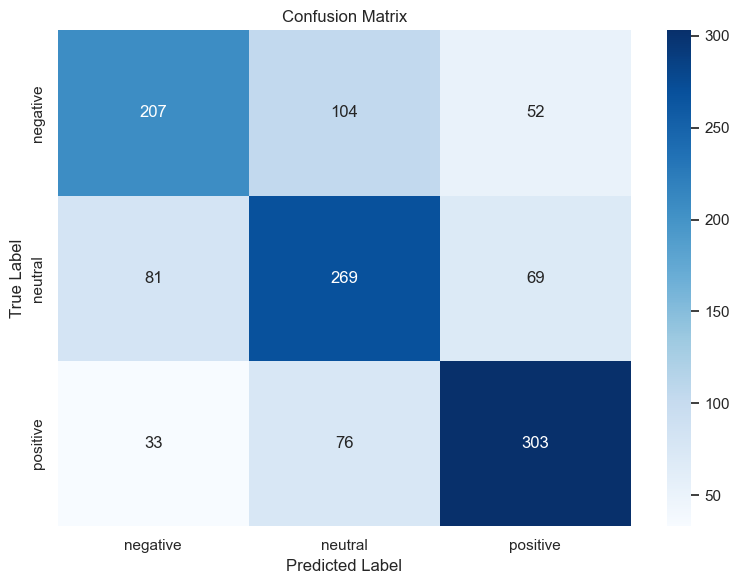

In [43]:
def get_prediction_probabilities(model, X):
    '''Return prediction probabilities for either Keras or NumPy model.'''
    if TF_AVAILABLE:
        return model.predict(X, verbose=0)
    return model.predict_proba(X)


def fallback_confusion_matrix(y_true, y_pred, labels):
    matrix = np.zeros((len(labels), len(labels)), dtype=int)
    label_to_position = {label: position for position, label in enumerate(labels)}
    for true_label, predicted_label in zip(y_true, y_pred):
        matrix[label_to_position[true_label], label_to_position[predicted_label]] += 1
    return matrix


def fallback_precision_recall_f1(y_true, y_pred, labels):
    rows = []
    total_support = len(y_true)
    weighted_precision = 0.0
    weighted_recall = 0.0
    weighted_f1 = 0.0

    for label in labels:
        tp = int(np.sum((y_true == label) & (y_pred == label)))
        fp = int(np.sum((y_true != label) & (y_pred == label)))
        fn = int(np.sum((y_true == label) & (y_pred != label)))
        support = int(np.sum(y_true == label))

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

        rows.append((label, precision, recall, f1, support))
        weighted_precision += precision * support
        weighted_recall += recall * support
        weighted_f1 += f1 * support

    weighted_precision /= max(total_support, 1)
    weighted_recall /= max(total_support, 1)
    weighted_f1 /= max(total_support, 1)

    return rows, weighted_precision, weighted_recall, weighted_f1


def print_fallback_classification_report(y_true, y_pred, class_names):
    labels = np.arange(len(class_names))
    rows, weighted_precision, weighted_recall, weighted_f1 = fallback_precision_recall_f1(y_true, y_pred, labels)

    print(f"{'class':<12} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>10}")
    for label, precision, recall, f1, support in rows:
        print(f"{class_names[label]:<12} {precision:>10.4f} {recall:>10.4f} {f1:>10.4f} {support:>10}")
    print(f"{'weighted avg':<12} {weighted_precision:>10.4f} {weighted_recall:>10.4f} {weighted_f1:>10.4f} {len(y_true):>10}")


y_pred_proba = get_prediction_probabilities(model, X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

test_accuracy = float(np.mean(y_pred == y_test))

if SKLEARN_AVAILABLE:
    precision, recall, f1, _ = sklearn_prfs(y_test, y_pred, average="weighted", zero_division=0)
else:
    _, precision, recall, f1 = fallback_precision_recall_f1(y_test, y_pred, np.arange(num_classes))

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-score: {f1:.4f}")

print("\nClassification Report:")
if SKLEARN_AVAILABLE:
    print(
        sklearn_classification_report(
            y_test,
            y_pred,
            labels=np.arange(num_classes),
            target_names=class_names,
            zero_division=0,
        )
    )
else:
    print_fallback_classification_report(y_test, y_pred, class_names)

if SKLEARN_AVAILABLE:
    cm = sklearn_confusion_matrix(y_test, y_pred, labels=np.arange(num_classes))
else:
    cm = fallback_confusion_matrix(y_test, y_pred, labels=np.arange(num_classes))

cm_table = pd.DataFrame(cm, index=class_names, columns=class_names)
print("\nConfusion Matrix:")
display(cm_table)

if MATPLOTLIB_AVAILABLE:
    plt.figure(figsize=(8, 6))
    if SEABORN_AVAILABLE:
        sns.heatmap(cm_table, annot=True, fmt="d", cmap="Blues")
    else:
        plt.imshow(cm, cmap="Blues")
        plt.colorbar()
        plt.xticks(np.arange(num_classes), class_names, rotation=45, ha="right")
        plt.yticks(np.arange(num_classes), class_names)
        for i in range(num_classes):
            for j in range(num_classes):
                plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


## 14. Training Curves

Training curves show whether the model is learning properly.

- If training accuracy increases but validation accuracy stays low, the model may be overfitting.
- If both training and validation accuracy are low, the model may need better features, more training, or a stronger architecture.


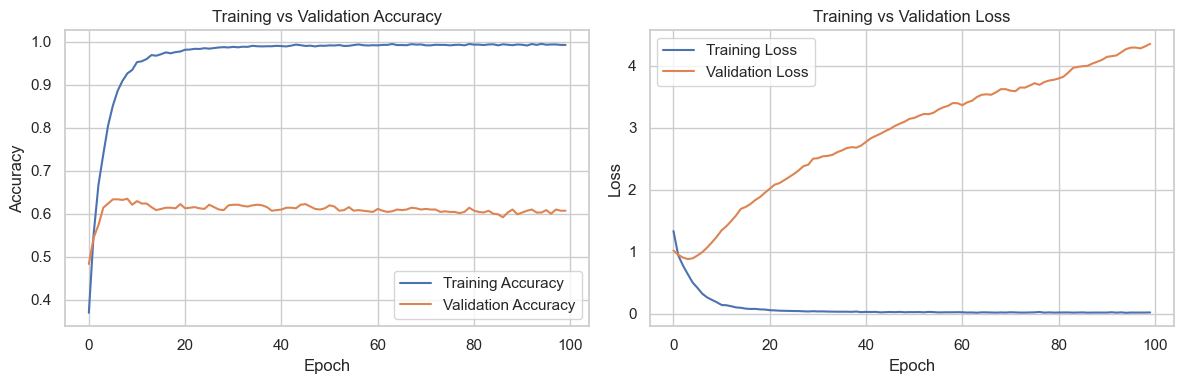

In [44]:
def plot_training_curves(history):
    '''Plot training and validation accuracy/loss if matplotlib is available.'''
    if not MATPLOTLIB_AVAILABLE:
        print("Matplotlib is not available. Showing final metrics instead.")
        print("Final training accuracy:", round(history["accuracy"][-1], 4))
        if history.get("val_accuracy"):
            print("Final validation accuracy:", round(history["val_accuracy"][-1], 4))
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.get("accuracy", []), label="Training Accuracy")
    axes[0].plot(history.get("val_accuracy", []), label="Validation Accuracy")
    axes[0].set_title("Training vs Validation Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(history.get("loss", []), label="Training Loss")
    axes[1].plot(history.get("val_loss", []), label="Validation Loss")
    axes[1].set_title("Training vs Validation Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_training_curves(history)


### Evaluation Interpretation

The model predicts the three sentiment labels present in `LabeledText.xlsx`: negative, neutral, and positive.

The score values depend on the train-test split and the available libraries. If TensorFlow and scikit-learn are installed, the notebook uses those libraries. If they are not installed, the notebook still trains using the NumPy fallback model.

Since this dataset does not include real audio or video, the current performance mainly measures text-based sentiment classification. Audio/video features are included in the pipeline so the project structure remains multimodal and can be extended later.


## 15. Prediction Function

The prediction function accepts:

- `text`
- `audio_path`
- `video_path`

For the current dataset, `audio_path` and `video_path` can be left blank. The function will use text features and zero-vector fallbacks for unavailable audio/video.

The predicted label will be one of the dataset labels:

- `negative`
- `neutral`
- `positive`


In [45]:
def predict_sentiment(text, audio_path="", video_path="", show_output=True):
    '''Predict sentiment for one text/audio/video sample.'''
    text_vector = transform_text_inputs([text])
    audio_vector = extract_audio_features(audio_path).reshape(1, -1)
    video_vector = extract_video_features(video_path).reshape(1, -1)

    fused_vector = np.concatenate(
        [text_vector, audio_vector, video_vector],
        axis=1,
    ).astype(np.float32)

    fused_vector_scaled = scaler.transform(fused_vector).astype(np.float32)
    probabilities = get_prediction_probabilities(model, fused_vector_scaled)[0]

    predicted_index = int(np.argmax(probabilities))
    predicted_label = label_encoder.inverse_transform([predicted_index])[0]
    confidence = float(probabilities[predicted_index])

    if show_output:
        print("Input text:", text)
        print("Predicted sentiment:", predicted_label)
        print(f"Confidence score: {confidence:.4f}")

        probability_table = pd.DataFrame(
            {
                "label": class_names,
                "probability": probabilities,
            }
        ).sort_values("probability", ascending=False)
        display(probability_table)

    return predicted_label, confidence, probabilities


print("Example prediction:")
predict_sentiment("I am very happy and excited about this amazing result")


Example prediction:
Input text: I am very happy and excited about this amazing result
Predicted sentiment: positive
Confidence score: 1.0000


,label,probability
2,positive,1.000000e+00
0,negative,4.992991e-17
1,neutral,1.871708e-20


('positive',
 1.0,
 array([4.9929906e-17, 1.8717081e-20, 1.0000000e+00], dtype=float32))

## 16. Predictions on Actual Dataset Samples

This section tests the prediction function on real captions from `LabeledText.xlsx`.

It prints the actual label from the dataset and the predicted label from the trained model.


In [46]:
sample_rows = (
    df.groupby("label", group_keys=False)
    .apply(lambda group: group.sample(2, random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

prediction_rows = []

for _, row in sample_rows.iterrows():
    predicted_label, confidence, _ = predict_sentiment(
        row["text"],
        row["audio_path"],
        row["video_path"],
        show_output=False,
    )
    prediction_rows.append(
        {
            "caption": row["text"][:120],
            "actual_label": row["label"],
            "predicted_label": predicted_label,
            "confidence": round(confidence, 4),
        }
    )

display(pd.DataFrame(prediction_rows))


,caption,actual_label,predicted_label,confidence
0,"RT @TheAVClub: On its new album, Antarctigo Ve...",negative,negative,1.0000
1,York Wallcoverings Jewel Box Marquise 27' x 27...,negative,negative,1.0000
2,@Selinatowerz P.S. I battle you with my #amiib...,neutral,neutral,1.0000
3,RT @BlueGreyFB: Trey Udoffia (@Trey_Dizzle7) w...,neutral,neutral,1.0000
4,about to see #ArvoPart for @MIFestival!! saw t...,positive,positive,1.0000
5,Setting up for #LochFyne at @thehubmk #Excited...,positive,positive,0.9999


## 17. Conclusion

This notebook built a complete sentiment analysis pipeline using the dataset added to this folder.

What was completed:

1. Loaded `LabeledText.xlsx`.
2. Used `Caption` as text input and `LABEL` as the target class.
3. Cleaned social-media style text.
4. Extracted text features using TF-IDF.
5. Included audio and video feature extraction functions with safe fallbacks.
6. Performed early fusion by concatenating text, audio, and video vectors.
7. Trained a dense neural network classifier.
8. Evaluated the model using accuracy, precision, recall, F1-score, and confusion matrix.
9. Created a reusable prediction function.
10. Generated predictions on real dataset samples.

Because the provided dataset contains text only, the current model mainly learns from captions. To make the project truly multimodal, add matching audio and video files with the same file stems as `File Name`, or add `audio_path` and `video_path` columns to the dataset.

### Future Improvements

1. Use a true multimodal benchmark such as CMU-MOSI, CMU-MOSEI, MELD, or IEMOCAP.
2. Use pretrained BERT embeddings for text.
3. Extract MFCC features from real audio clips.
4. Use ResNet, VGG16, MobileNet, or a custom CNN for video features.
5. Try late fusion, hybrid fusion, or attention-based fusion.
6. Deploy the final model using Streamlit or FastAPI.


## How to Explain This Project in an Interview

This project predicts sentiment using a multimodal machine learning pipeline. The dataset used here contains text captions and labels: negative, neutral, and positive.

First, the captions are cleaned by removing noise such as URLs, mentions, and special characters. Then the text is converted into numerical TF-IDF features. The notebook also contains functions for audio MFCC extraction and video frame feature extraction. Since the current dataset does not include real audio/video files, those modalities use zero-vector fallbacks, but the pipeline is ready for real media files.

After feature extraction, text, audio, and video vectors are concatenated using early fusion. The fused vector is normalized and passed into a dense neural network classifier. The model is trained using categorical cross-entropy and an Adam-style optimizer, then evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

The key idea is that sentiment can be understood better when linguistic, acoustic, and visual cues are combined. In the current dataset, the model learns from text; with audio and video files added, the same structure becomes a full multimodal sentiment analysis system.
